# 02 — Feature Engineering
**CamAgri Agricultural Risk Assessment Platform**

This notebook engineers all features required by the four ML pipelines:
- **Price forecasting** — temporal, lag, rolling, seasonality, trend features
- **Crop suitability** — soil × climate interaction features
- **Yield prediction** — agronomic composite features
- **Risk scoring** — financial, climate, agronomic risk indicators

**Sections**
1. Setup & data loading
2. Price feature engineering
3. Yield / suitability feature engineering
4. Risk scoring feature engineering
5. Encoding & scaling pipelines
6. Feature selection & importance
7. Save engineered datasets

## 1. Setup & Data Loading

In [1]:
import warnings, os
import numpy as np
import pyarrow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, PowerTransformer,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import (
    mutual_info_regression, mutual_info_classif,
    SelectKBest, f_regression,
)
from sklearn.decomposition import PCA
import joblib

warnings.filterwarnings('ignore')

DATA_ROOT    = Path('../data')
PRICES_DIR   = DATA_ROOT / 'prices'
YIELDS_PATH  = DATA_ROOT / 'yields'  / 'cameroon_yields.csv'
SOIL_PATH    = DATA_ROOT / 'soil'    / 'cameroon_soil.csv'
CLIMATE_PATH = DATA_ROOT / 'climate' / 'cameroon_climate.csv'
OUTPUT_DIR   = Path('../outputs/features')
MODELS_DIR   = Path('../models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':'#0d0d0d','axes.facecolor':'#111111',
    'axes.edgecolor':'#333333','text.color':'#cccccc',
    'axes.labelcolor':'#cccccc','axes.titlecolor':'#ffffff',
    'xtick.color':'#666666','ytick.color':'#666666',
    'grid.color':'#222222','grid.alpha':0.5,'font.size':11,
})
LIME = '#CAFF00'

CROPS   = ['maize','rice','cassava','cocoyam','plantain','cocoa','coffee',
           'groundnut','beans','tomato','onion','potato','palm_oil','sorghum']
REGIONS = ['North West','South West','West','Littoral','Adamawa',
           'Far North','Centre','East','North','South']

print('Setup complete.')

Setup complete.


In [2]:
# Load datasets
price_frames = [pd.read_csv(f, parse_dates=['date']) for f in sorted(PRICES_DIR.glob('*_price.csv'))]
prices  = pd.concat(price_frames, ignore_index=True)
yields  = pd.read_csv(YIELDS_PATH)
soil    = pd.read_csv(SOIL_PATH)
climate = pd.read_csv(CLIMATE_PATH)

print(f'prices : {prices.shape}')
print(f'yields : {yields.shape}')
print(f'soil   : {soil.shape}')
print(f'climate: {climate.shape}')

prices : (58240, 7)
yields : (3000, 13)
soil   : (1000, 11)
climate: (540, 8)


## 2. Price Feature Engineering

In [3]:
# ── 2.1 Build national weekly price series (average across regions) ────────
price_national = (
    prices
    .groupby(['date','crop'])['price_xaf_per_kg']
    .mean()
    .reset_index()
    .sort_values(['crop','date'])
    .reset_index(drop=True)
)
price_national['date'] = pd.to_datetime(price_national['date'])
print('National weekly price shape:', price_national.shape)
print(price_national.head())

National weekly price shape: (5824, 3)
        date   crop  price_xaf_per_kg
0 2016-01-01  beans             797.5
1 2016-01-08  beans             795.5
2 2016-01-15  beans             952.6
3 2016-01-22  beans             972.8
4 2016-01-29  beans             914.3


In [4]:
# ── 2.2 Temporal features ─────────────────────────────────────────────────
def add_temporal_features(df: pd.DataFrame, date_col='date') -> pd.DataFrame:
    """Add calendar and Fourier seasonality features to a time-indexed DataFrame."""
    df = df.copy()
    d = df[date_col]
    
    # Calendar
    df['year']        = d.dt.year
    df['month']       = d.dt.month
    df['week']        = d.dt.isocalendar().week.astype(int)
    df['quarter']     = d.dt.quarter
    df['day_of_year'] = d.dt.dayofyear
    df['week_of_year']= d.dt.isocalendar().week.astype(int)

    # Binary season flags (Cameroon dry/rainy)
    df['is_dry_season']   = d.dt.month.isin([11,12,1,2,3]).astype(int)
    df['is_rainy_season'] = (1 - df['is_dry_season'])
    df['is_harvest_q4']   = d.dt.month.isin([9,10,11]).astype(int)  # main harvest
    df['is_lean_season']  = d.dt.month.isin([6,7,8]).astype(int)    # pre-harvest scarcity

    # Fourier pairs — annual cycle (52 weeks) and biannual (26 weeks)
    for k, period in [(1, 52), (2, 52), (1, 26)]:
        df[f'sin_w{period}_k{k}'] = np.sin(2 * np.pi * k * df['week_of_year'] / period)
        df[f'cos_w{period}_k{k}'] = np.cos(2 * np.pi * k * df['week_of_year'] / period)

    # Month Fourier
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

    # Linear time trend (weeks since start)
    t0 = df[date_col].min()
    df['trend_weeks'] = ((df[date_col] - t0).dt.days / 7).astype(int)
    df['trend_sq']    = df['trend_weeks'] ** 2  # allows non-linear trend

    return df


price_national = add_temporal_features(price_national)
print('Temporal features added:', [c for c in price_national.columns if c not in ['date','crop','price_xaf_per_kg']])

Temporal features added: ['year', 'month', 'week', 'quarter', 'day_of_year', 'week_of_year', 'is_dry_season', 'is_rainy_season', 'is_harvest_q4', 'is_lean_season', 'sin_w52_k1', 'cos_w52_k1', 'sin_w52_k2', 'cos_w52_k2', 'sin_w26_k1', 'cos_w26_k1', 'sin_month', 'cos_month', 'trend_weeks', 'trend_sq']


In [5]:
# ── 2.3 Lag features ──────────────────────────────────────────────────────
def add_lag_features(df: pd.DataFrame, target='price_xaf_per_kg',
                     lags=(1,2,3,4,8,12,26,52)) -> pd.DataFrame:
    """Add lagged values of the target variable per crop."""
    df = df.sort_values(['crop','date']).copy()
    for lag in lags:
        df[f'lag_{lag}w'] = df.groupby('crop')[target].shift(lag)
    return df

price_national = add_lag_features(price_national)
lag_cols = [c for c in price_national.columns if c.startswith('lag_')]
print('Lag features:', lag_cols)
print(f'NaN from lags: {price_national[lag_cols].isnull().sum().max()} max rows dropped per feature')

Lag features: ['lag_1w', 'lag_2w', 'lag_3w', 'lag_4w', 'lag_8w', 'lag_12w', 'lag_26w', 'lag_52w']
NaN from lags: 728 max rows dropped per feature


In [6]:
# ── 2.4 Rolling statistics ────────────────────────────────────────────────
def add_rolling_features(df: pd.DataFrame, target='price_xaf_per_kg',
                         windows=(4, 8, 12, 26)) -> pd.DataFrame:
    """Rolling mean, std, min, max, and momentum."""
    df = df.sort_values(['crop','date']).copy()
    grp = df.groupby('crop')[target]
    for w in windows:
        df[f'roll_mean_{w}w']  = grp.transform(lambda x: x.shift(1).rolling(w).mean())
        df[f'roll_std_{w}w']   = grp.transform(lambda x: x.shift(1).rolling(w).std())
        df[f'roll_min_{w}w']   = grp.transform(lambda x: x.shift(1).rolling(w).min())
        df[f'roll_max_{w}w']   = grp.transform(lambda x: x.shift(1).rolling(w).max())
        # Momentum: current vs rolling mean
        df[f'momentum_{w}w']   = df[target].shift(1) / (df[f'roll_mean_{w}w'] + 1e-9)
    # Trend acceleration (2nd difference)
    df['price_diff_1w'] = grp.transform(lambda x: x.shift(1).diff(1))
    df['price_diff_4w'] = grp.transform(lambda x: x.shift(1).diff(4))
    df['price_pct_4w']  = grp.transform(lambda x: x.shift(1).pct_change(4))
    # Coefficient of variation (rolling 12w)
    df['roll_cv_12w'] = df['roll_std_12w'] / (df['roll_mean_12w'] + 1e-9)
    return df

price_national = add_rolling_features(price_national)
roll_cols = [c for c in price_national.columns if c.startswith('roll_') or c.startswith('momentum_') or 'diff' in c or 'pct' in c]
print(f'Rolling features added ({len(roll_cols)}):', roll_cols[:10], '...')

Rolling features added (24): ['roll_mean_4w', 'roll_std_4w', 'roll_min_4w', 'roll_max_4w', 'momentum_4w', 'roll_mean_8w', 'roll_std_8w', 'roll_min_8w', 'roll_max_8w', 'momentum_8w'] ...


In [7]:
# ── 2.5 Price decomposition — trend + residual ────────────────────────────
def add_decomposition_features(df: pd.DataFrame, target='price_xaf_per_kg') -> pd.DataFrame:
    """
    Compute a simple HP-filter-style trend and residual.
    Uses 52-week centred rolling mean as trend proxy.
    """
    df = df.sort_values(['crop','date']).copy()
    grp = df.groupby('crop')[target]
    df['trend_52w']    = grp.transform(lambda x: x.rolling(52, center=True, min_periods=26).mean())
    df['residual_52w'] = df[target] - df['trend_52w']
    df['price_log']    = np.log1p(df[target])  # log-transform for stationarity
    df['log_diff_1w']  = grp.transform(lambda x: np.log1p(x).diff(1))
    return df

price_national = add_decomposition_features(price_national)
print('Decomposition features added: trend_52w, residual_52w, price_log, log_diff_1w')

Decomposition features added: trend_52w, residual_52w, price_log, log_diff_1w


In [8]:
# ── 2.6 Merge climate into price data (national monthly averages) ──────────
clim_monthly = (
    climate
    .groupby(['year','month'])[['rainfall_mm','avg_temp_c','drought_index','flood_risk']]
    .mean()
    .reset_index()
)
price_national = price_national.merge(
    clim_monthly, on=['year','month'], how='left'
)

# Lagged rainfall (planting decisions made months ahead)
price_national = price_national.sort_values(['crop','date'])
for lag_m in [1, 2, 3]:
    price_national[f'rainfall_lag_{lag_m}m'] = (
        price_national.groupby('crop')['rainfall_mm'].shift(lag_m * 4)
    )

print('Climate features merged.')
print('Final price feature set shape:', price_national.shape)
print('\nFeature groups summary:')
groups = {
    'temporal':    [c for c in price_national.columns if any(x in c for x in ['year','month','week','quarter','season','trend_weeks','sin','cos','harvest','lean','dry','rainy'])],
    'lags':        [c for c in price_national.columns if c.startswith('lag_')],
    'rolling':     roll_cols,
    'decomp':      ['trend_52w','residual_52w','price_log','log_diff_1w'],
    'climate':     ['rainfall_mm','avg_temp_c','drought_index','flood_risk'] + [c for c in price_national.columns if 'rainfall_lag' in c],
}
for g, cols in groups.items():
    print(f'  {g:10s}: {len(cols)} features')

Climate features merged.
Final price feature set shape: (5824, 66)

Feature groups summary:
  temporal  : 19 features
  lags      : 8 features
  rolling   : 24 features
  decomp    : 4 features
  climate   : 7 features


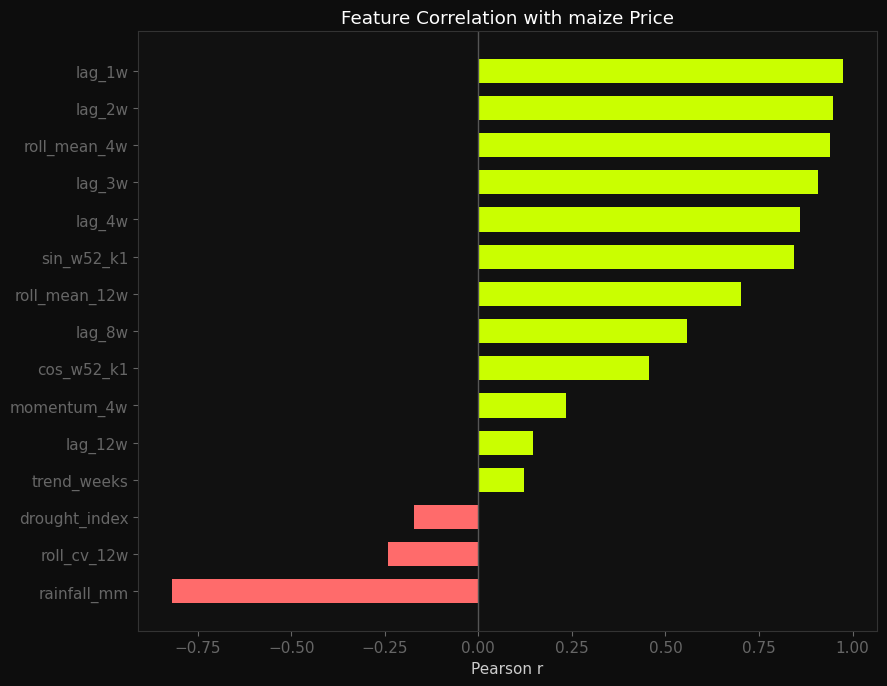

In [9]:
# ── 2.7 Visualise feature correlations with price ──────────────────────────
sample_crop = 'maize'
df_crop = price_national[price_national.crop == sample_crop].dropna(subset=['price_xaf_per_kg'])

feature_cols = (
    [c for c in price_national.columns if c.startswith('lag_')][:6] +
    ['roll_mean_4w','roll_mean_12w','roll_cv_12w','momentum_4w',
     'sin_w52_k1','cos_w52_k1','trend_weeks','rainfall_mm','drought_index']
)
feature_cols = [c for c in feature_cols if c in df_crop.columns]

corrs = df_crop[feature_cols + ['price_xaf_per_kg']].corr()['price_xaf_per_kg'].drop('price_xaf_per_kg').sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = [LIME if v > 0 else '#FF6B6B' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, edgecolor='none', height=0.65)
ax.axvline(0, color='#555555', lw=1)
ax.set_title(f'Feature Correlation with {sample_crop} Price')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'price_feature_correlations.png', dpi=140, bbox_inches='tight')
plt.show()

## 3. Yield / Suitability Feature Engineering

In [10]:
# ── 3.1 Agronomic composite features ──────────────────────────────────────
def engineer_yield_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Soil quality index (pH optimal range [5.5–7.0]) ────────────────────
    df['soil_ph_deviation'] = np.abs(df['soil_ph'] - 6.2)           # 6.2 = broad optimum
    df['soil_ph_optimal']   = ((df['soil_ph'] >= 5.5) & (df['soil_ph'] <= 7.0)).astype(int)
    df['soil_ph_sq']        = df['soil_ph'] ** 2                     # non-linear pH response

    # ── Water adequacy ─────────────────────────────────────────────────────
    df['rain_log']          = np.log1p(df['rainfall_mm'])
    df['rain_deficit']      = np.maximum(0, 1200 - df['rainfall_mm'])   # below 1200mm = stress
    df['rain_surplus']      = np.maximum(0, df['rainfall_mm'] - 2500)   # above 2500mm = flooding risk
    df['rain_optimal_band'] = ((df['rainfall_mm'] >= 800) & (df['rainfall_mm'] <= 2500)).astype(int)

    # ── Temperature stress ─────────────────────────────────────────────────
    df['temp_deviation']    = np.abs(df['temperature_c'] - 25.0)    # 25°C broad optimum
    df['heat_stress']       = (df['temperature_c'] > 32).astype(int)
    df['cold_stress']       = (df['temperature_c'] < 15).astype(int)

    # ── Growing condition index (GCI) — composite ─────────────────────────
    # Normalise components to [0,1]
    ph_score   = 1 - (df['soil_ph_deviation'] / 4).clip(0, 1)
    rain_score = (df['rainfall_mm'].clip(500, 3000) - 500) / 2500
    temp_score = 1 - (df['temp_deviation'] / 20).clip(0, 1)
    df['gci']  = (ph_score * 0.3 + rain_score * 0.4 + temp_score * 0.3).round(4)

    # ── Elevation zones ───────────────────────────────────────────────────
    df['elev_zone'] = pd.cut(
        df['elevation_m'],
        bins=[0, 200, 500, 1000, 2000, 5000],
        labels=['coastal','lowland','midland','highland','montane']
    ).astype(str)

    # ── Input intensity index ─────────────────────────────────────────────
    fert_map = {'none': 0, 'organic': 1, 'inorganic': 2, 'mixed': 3}
    df['fert_code']       = df['fertilizer_type'].map(fert_map).fillna(0)
    df['input_intensity'] = (df['irrigation'] * 0.5 + df['fert_code'] / 3 * 0.5).round(4)

    # ── Interaction terms ─────────────────────────────────────────────────
    df['irr_x_rain']     = df['irrigation'] * df['rainfall_mm']    # irrigation value lower in high-rain areas
    df['fert_x_rain']    = df['fert_code']  * df['rainfall_mm']    # fertiliser most effective with good rain
    df['ph_x_rain']      = df['soil_ph']    * df['rainfall_mm']    # leaching risk
    df['gci_x_input']    = df['gci']        * df['input_intensity']

    # ── Land size bands ───────────────────────────────────────────────────
    df['farm_size_band'] = pd.cut(
        df['land_size_ha'],
        bins=[0, 1, 5, 20, 100, 10000],
        labels=['subsistence','smallholder','medium','large','commercial']
    ).astype(str)

    # ── Log transform target for modelling ────────────────────────────────
    df['yield_log'] = np.log1p(df['yield_tons_per_ha'])

    return df


yields_fe = engineer_yield_features(yields)
new_cols = [c for c in yields_fe.columns if c not in yields.columns]
print(f'New features added ({len(new_cols)}): {new_cols}')

New features added (20): ['soil_ph_deviation', 'soil_ph_optimal', 'soil_ph_sq', 'rain_log', 'rain_deficit', 'rain_surplus', 'rain_optimal_band', 'temp_deviation', 'heat_stress', 'cold_stress', 'gci', 'elev_zone', 'fert_code', 'input_intensity', 'irr_x_rain', 'fert_x_rain', 'ph_x_rain', 'gci_x_input', 'farm_size_band', 'yield_log']


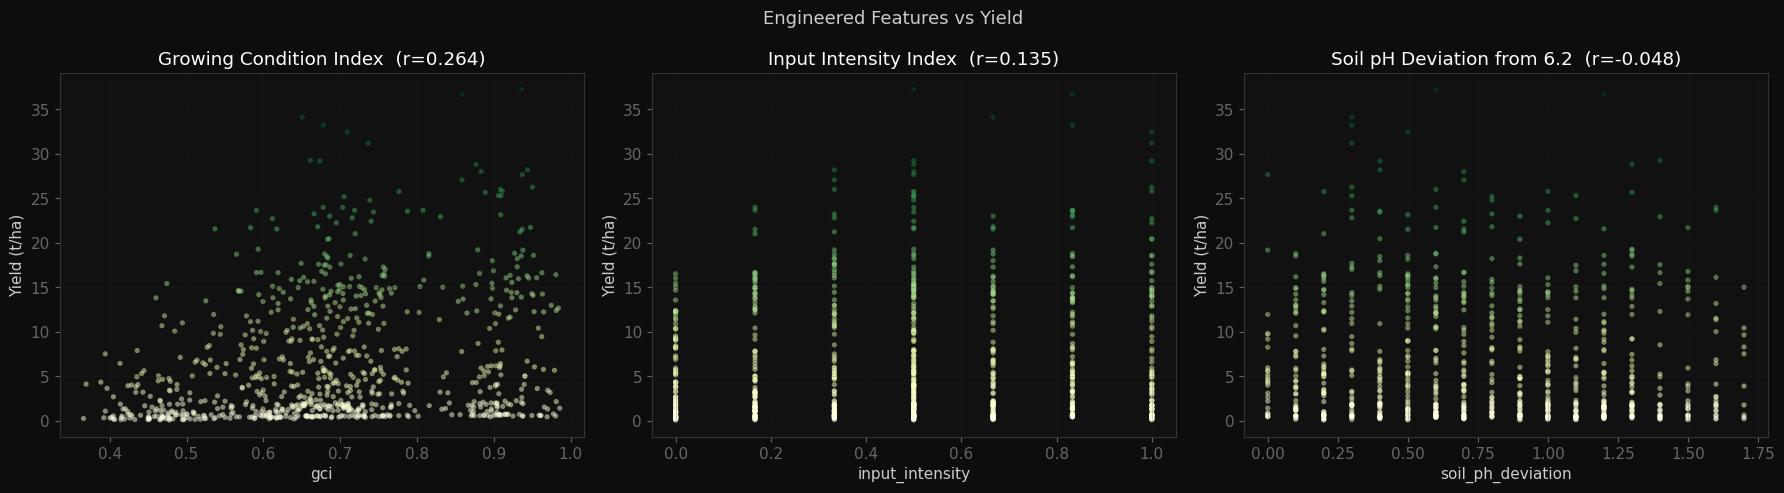

In [11]:
# ── 3.2 Visualise GCI vs yield ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (feat, lab) in zip(axes, [
    ('gci',            'Growing Condition Index'),
    ('input_intensity','Input Intensity Index'),
    ('soil_ph_deviation','Soil pH Deviation from 6.2'),
]):
    s = yields_fe.sample(min(800, len(yields_fe)), random_state=0)
    sc = ax.scatter(s[feat], s['yield_tons_per_ha'],
                    c=s['yield_tons_per_ha'], cmap='YlGn',
                    alpha=0.5, s=14, edgecolors='none')
    r, _ = stats.pearsonr(yields_fe[feat].dropna(), yields_fe.loc[yields_fe[feat].notna(), 'yield_tons_per_ha'])
    ax.set_title(f'{lab}  (r={r:.3f})')
    ax.set_xlabel(feat); ax.set_ylabel('Yield (t/ha)')
    ax.grid(True, alpha=0.2)

plt.suptitle('Engineered Features vs Yield', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'yield_engineered_features.png', dpi=140, bbox_inches='tight')
plt.show()

In [12]:
# ── 3.3 Crop encoding for suitability model ───────────────────────────────
def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    le_crop    = LabelEncoder().fit(CROPS)
    le_region  = LabelEncoder().fit(REGIONS)
    le_fert    = LabelEncoder().fit(['none','organic','inorganic','mixed'])

    df['crop_encoded']   = le_crop.transform(df['crop'])
    df['region_encoded'] = le_region.transform(df['region'])
    df['fert_encoded']   = le_fert.transform(df['fertilizer_type'])

    # Save encoders for inference
    joblib.dump(le_crop,   MODELS_DIR / 'le_crop.pkl')
    joblib.dump(le_region, MODELS_DIR / 'le_region.pkl')
    joblib.dump(le_fert,   MODELS_DIR / 'le_fert.pkl')

    return df

yields_fe = encode_categoricals(yields_fe)
print('Label encoders saved.')
print('Encoded columns:', ['crop_encoded','region_encoded','fert_encoded'])

Label encoders saved.
Encoded columns: ['crop_encoded', 'region_encoded', 'fert_encoded']


In [13]:
# ── 3.4 Outlier detection & treatment ─────────────────────────────────────
def cap_outliers_iqr(df: pd.DataFrame, col: str, factor: float = 3.0) -> pd.DataFrame:
    """Winsorise extreme outliers at IQR * factor."""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - factor * iqr, q3 + factor * iqr
    n_clipped = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    if n_clipped:
        print(f'  {col}: clipped {n_clipped} outliers to [{lo:.2f}, {hi:.2f}]')
    return df

print('=== Outlier treatment (3× IQR winsorisation) ===')
for col in ['yield_tons_per_ha','rainfall_mm','soil_ph','temperature_c']:
    yields_fe = cap_outliers_iqr(yields_fe, col)

print('Done.')

=== Outlier treatment (3× IQR winsorisation) ===
  yield_tons_per_ha: clipped 1 outliers to [-27.25, 39.20]
Done.


In [14]:
# ── 3.5 Build sklearn preprocessing pipeline ─────────────────────────────
YIELD_NUMERIC_FEATURES = [
    'soil_ph','rainfall_mm','temperature_c','humidity_pct','elevation_m',
    'land_size_ha','irrigation','fert_code',
    'soil_ph_deviation','rain_deficit','rain_surplus','temp_deviation',
    'gci','input_intensity','irr_x_rain','fert_x_rain','gci_x_input',
]

YIELD_CAT_FEATURES = ['crop_encoded','region_encoded']

numeric_transformer = Pipeline([
    ('robust_scaler', RobustScaler()),   # robust to remaining outliers
])

# Passthrough for already-encoded categoricals
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     YIELD_NUMERIC_FEATURES),
    ('cat', 'passthrough',           YIELD_CAT_FEATURES),
], remainder='drop')

# Fit on full dataset and save
X_yield = yields_fe[YIELD_NUMERIC_FEATURES + YIELD_CAT_FEATURES].dropna()
preprocessor.fit(X_yield)
joblib.dump(preprocessor, MODELS_DIR / 'yield_preprocessor.pkl')

print('Yield preprocessor saved.')
print(f'Feature matrix shape: {X_yield.shape}')

Yield preprocessor saved.
Feature matrix shape: (3000, 19)


## 4. Risk Scoring Feature Engineering

In [15]:
# ── 4.1 Financial risk features ───────────────────────────────────────────
# Compute historical price volatility per crop as financial risk proxy
price_vol = (
    prices.groupby('crop')['price_xaf_per_kg']
    .agg(
        price_mean   = 'mean',
        price_std    = 'std',
        price_cv     = lambda x: x.std() / x.mean(),
        price_p10    = lambda x: x.quantile(.10),
        price_p90    = lambda x: x.quantile(.90),
        price_iqr    = lambda x: x.quantile(.75) - x.quantile(.25),
    )
    .reset_index()
)
# Normalise CV to [0, 1] as financial_risk_score
price_vol['financial_risk_raw'] = price_vol['price_cv']
price_vol['financial_risk']     = (
    (price_vol['price_cv'] - price_vol['price_cv'].min()) /
    (price_vol['price_cv'].max() - price_vol['price_cv'].min())
)
print('=== FINANCIAL RISK SCORES BY CROP ===')
print(price_vol[['crop','price_cv','financial_risk']].sort_values('financial_risk', ascending=False).to_string(index=False))

=== FINANCIAL RISK SCORES BY CROP ===
     crop  price_cv  financial_risk
   tomato  0.430665        1.000000
    onion  0.337545        0.673396
 plantain  0.316243        0.598681
   potato  0.253010        0.376904
    maize  0.247048        0.355992
    beans  0.246744        0.354925
  cocoyam  0.218934        0.257387
  sorghum  0.216114        0.247497
groundnut  0.203672        0.203858
   coffee  0.186180        0.142507
  cassava  0.183071        0.131603
    cocoa  0.173614        0.098432
     rice  0.166015        0.071781
 palm_oil  0.145549        0.000000


In [16]:
# ── 4.2 Climate risk features per region ──────────────────────────────────
climate_risk = (
    climate.groupby('region')
    .agg(
        mean_rainfall   = ('rainfall_mm',  'mean'),
        cv_rainfall     = ('rainfall_mm',  lambda x: x.std()/x.mean()),
        drought_mean    = ('drought_index','mean'),
        flood_mean      = ('flood_risk',   'mean'),
        temp_mean       = ('avg_temp_c',   'mean'),
        temp_cv         = ('avg_temp_c',   lambda x: x.std()/x.mean()),
        low_rain_months = ('rainfall_mm',  lambda x: (x < 50).mean()),
    )
    .reset_index()
)

# Composite climate risk score [0, 1]
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

climate_risk['climate_risk'] = (
    norm(climate_risk['drought_mean'])    * 0.35 +
    norm(climate_risk['cv_rainfall'])     * 0.25 +
    norm(climate_risk['flood_mean'])      * 0.20 +
    norm(climate_risk['low_rain_months']) * 0.20
).round(4)

print('=== CLIMATE RISK SCORES BY REGION ===')
print(climate_risk[['region','climate_risk','drought_mean','flood_mean']].sort_values('climate_risk', ascending=False).to_string(index=False))

=== CLIMATE RISK SCORES BY REGION ===
   region  climate_risk  drought_mean  flood_mean
    North        0.8023      0.776111    0.106481
Far North        0.7915      0.773981    0.098241
 Littoral        0.3069      0.068981    0.818981
     West        0.2312      0.226481    0.347037
   Center        0.2236      0.224259    0.366019


In [17]:
# ── 4.3 Agronomic risk features ───────────────────────────────────────────
def compute_agronomic_risk(row) -> float:
    """
    Rule-based agronomic risk score [0, 1].
    Combines soil pH, rainfall adequacy, temperature extremes.
    """
    risk = 0.0
    ph   = row['soil_ph']
    rain = row['rainfall_mm']
    temp = row['temperature_c']

    # pH penalties
    if ph < 4.5 or ph > 8.5: risk += 0.35
    elif ph < 5.0 or ph > 8.0: risk += 0.20
    elif ph < 5.5 or ph > 7.5: risk += 0.10

    # Rainfall penalties
    if rain < 300 or rain > 4500: risk += 0.30
    elif rain < 500 or rain > 3500: risk += 0.18
    elif rain < 700 or rain > 3000: risk += 0.08

    # Temperature penalties
    if temp > 40 or temp < 10: risk += 0.25
    elif temp > 36 or temp < 13: risk += 0.15
    elif temp > 33 or temp < 16: risk += 0.07

    return min(round(risk, 3), 1.0)

yields_fe['agronomic_risk'] = yields_fe.apply(compute_agronomic_risk, axis=1)

print('Agronomic risk distribution:')
print(yields_fe['agronomic_risk'].describe().round(3))

Agronomic risk distribution:
count    3000.000
mean        0.074
std         0.095
min         0.000
25%         0.000
50%         0.000
75%         0.150
max         0.450
Name: agronomic_risk, dtype: float64


In [18]:
# ── 4.4 Build combined risk dataset ───────────────────────────────────────
MARKET_ACCESS_SCORES = {'poor': 0.85, 'moderate': 0.55, 'good': 0.30, 'excellent': 0.10}

risk_df = yields_fe[['crop','region','land_size_ha','soil_ph','rainfall_mm',
                      'temperature_c','irrigation','fert_code','agronomic_risk']].copy()

# Merge financial risk per crop
risk_df = risk_df.merge(price_vol[['crop','financial_risk']], on='crop', how='left')

# Merge climate risk per region
risk_df = risk_df.merge(climate_risk[['region','climate_risk']], on='region', how='left')

# Simulate market_access (in real pipeline this comes from request payload)
import random; random.seed(42)
risk_df['market_access'] = [random.choice(['poor','moderate','good','excellent']) for _ in range(len(risk_df))]
risk_df['market_risk']   = risk_df['market_access'].map(MARKET_ACCESS_SCORES)

# Blended financial risk (intrinsic + market)
risk_df['financial_risk_blended'] = (risk_df['financial_risk'] * 0.6 + risk_df['market_risk'] * 0.4).round(4)

# Overall risk score
risk_df['overall_risk'] = (
    risk_df['financial_risk_blended'] * 0.35 +
    risk_df['climate_risk']           * 0.40 +
    risk_df['agronomic_risk']         * 0.25
).clip(0, 1).round(4)

risk_df['risk_level'] = pd.cut(
    risk_df['overall_risk'],
    bins=[0, 0.35, 0.55, 0.75, 1.0],
    labels=['low','medium','high','critical']
)

print('Risk dataset shape:', risk_df.shape)
print('\nRisk level distribution:')
print(risk_df['risk_level'].value_counts())

Risk dataset shape: (3000, 16)

Risk level distribution:
risk_level
low         586
medium      551
high        113
critical      0
Name: count, dtype: int64


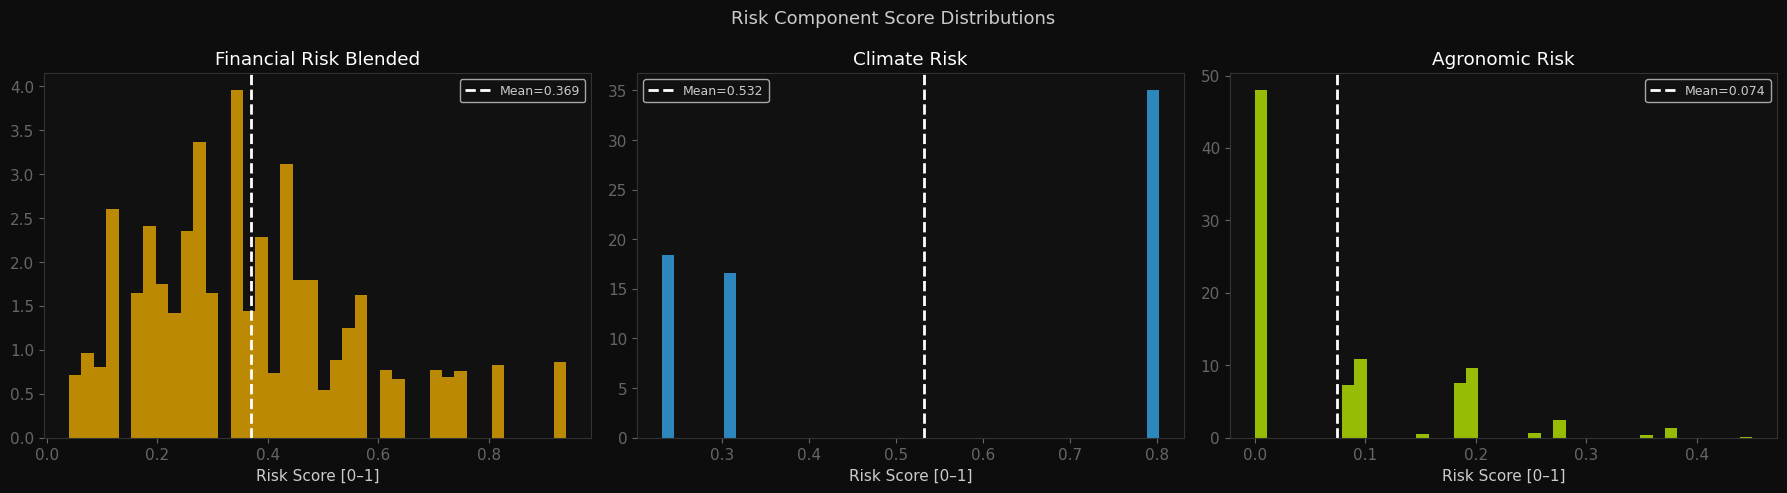

In [19]:
# ── 4.5 Risk feature visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
risk_components = ['financial_risk_blended','climate_risk','agronomic_risk']
for ax, comp, c in zip(axes, risk_components, ['#FFB800','#38B6FF',LIME]):
    ax.hist(risk_df[comp].dropna(), bins=40, color=c, alpha=0.72, edgecolor='none', density=True)
    ax.axvline(risk_df[comp].mean(), color='white', lw=2, linestyle='--', label=f'Mean={risk_df[comp].mean():.3f}')
    ax.set_title(comp.replace('_',' ').title())
    ax.set_xlabel('Risk Score [0–1]')
    ax.legend(fontsize=9)
fig.suptitle('Risk Component Score Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'risk_component_distributions.png', dpi=140, bbox_inches='tight')
plt.show()

## 5. Encoding & Scaling Pipelines

In [20]:
# ── 5.1 Price forecasting feature matrix ──────────────────────────────────
PRICE_FEATURE_COLS = [
    'trend_weeks','trend_sq',
    'sin_w52_k1','cos_w52_k1','sin_w52_k2','cos_w52_k2',
    'sin_w26_k1','cos_w26_k1',
    'sin_month','cos_month',
    'is_dry_season','is_harvest_q4','is_lean_season',
    'lag_1w','lag_4w','lag_8w','lag_12w','lag_52w',
    'roll_mean_4w','roll_mean_12w','roll_std_12w',
    'momentum_4w','price_diff_1w','price_pct_4w','roll_cv_12w',
    'rainfall_mm','drought_index',
]
PRICE_FEATURE_COLS = [c for c in PRICE_FEATURE_COLS if c in price_national.columns]

# Build per-crop scalers
price_scalers = {}
for crop in CROPS:
    df_c = price_national[price_national.crop == crop][PRICE_FEATURE_COLS].dropna()
    if len(df_c) == 0: continue
    scaler = RobustScaler()
    scaler.fit(df_c)
    price_scalers[crop] = scaler

joblib.dump(price_scalers, MODELS_DIR / 'price_scalers.pkl')
print(f'Price scalers saved for {len(price_scalers)} crops.')
print(f'Price feature count: {len(PRICE_FEATURE_COLS)}')

Price scalers saved for 14 crops.
Price feature count: 27


In [21]:
# ── 5.2 Suitability feature matrix ────────────────────────────────────────
SUIT_FEATURES = [
    'soil_ph','rainfall_mm','temperature_c','humidity_pct','elevation_m',
    'soil_ph_deviation','rain_deficit','rain_surplus','temp_deviation',
    'gci','rain_optimal_band','soil_ph_optimal','heat_stress','cold_stress',
]
SUIT_FEATURES = [c for c in SUIT_FEATURES if c in yields_fe.columns]

suit_scaler = StandardScaler()
X_suit = yields_fe[SUIT_FEATURES].dropna()
suit_scaler.fit(X_suit)
joblib.dump(suit_scaler, MODELS_DIR / 'suitability_scaler.pkl')
print(f'Suitability scaler saved. Features: {SUIT_FEATURES}')

Suitability scaler saved. Features: ['soil_ph', 'rainfall_mm', 'temperature_c', 'humidity_pct', 'elevation_m', 'soil_ph_deviation', 'rain_deficit', 'rain_surplus', 'temp_deviation', 'gci', 'rain_optimal_band', 'soil_ph_optimal', 'heat_stress', 'cold_stress']


In [22]:
# ── 5.3 Risk feature matrix ────────────────────────────────────────────────
RISK_FEATURES = [
    'financial_risk_blended','climate_risk','agronomic_risk',
    'soil_ph','rainfall_mm','temperature_c',
]
RISK_FEATURES_AVAIL = [c for c in RISK_FEATURES if c in risk_df.columns]

risk_scaler = MinMaxScaler()
X_risk = risk_df[RISK_FEATURES_AVAIL].dropna()
risk_scaler.fit(X_risk)
joblib.dump(risk_scaler, MODELS_DIR / 'risk_scaler.pkl')
print(f'Risk scaler saved. Features: {RISK_FEATURES_AVAIL}')

Risk scaler saved. Features: ['financial_risk_blended', 'climate_risk', 'agronomic_risk', 'soil_ph', 'rainfall_mm', 'temperature_c']


## 6. Feature Selection & Importance

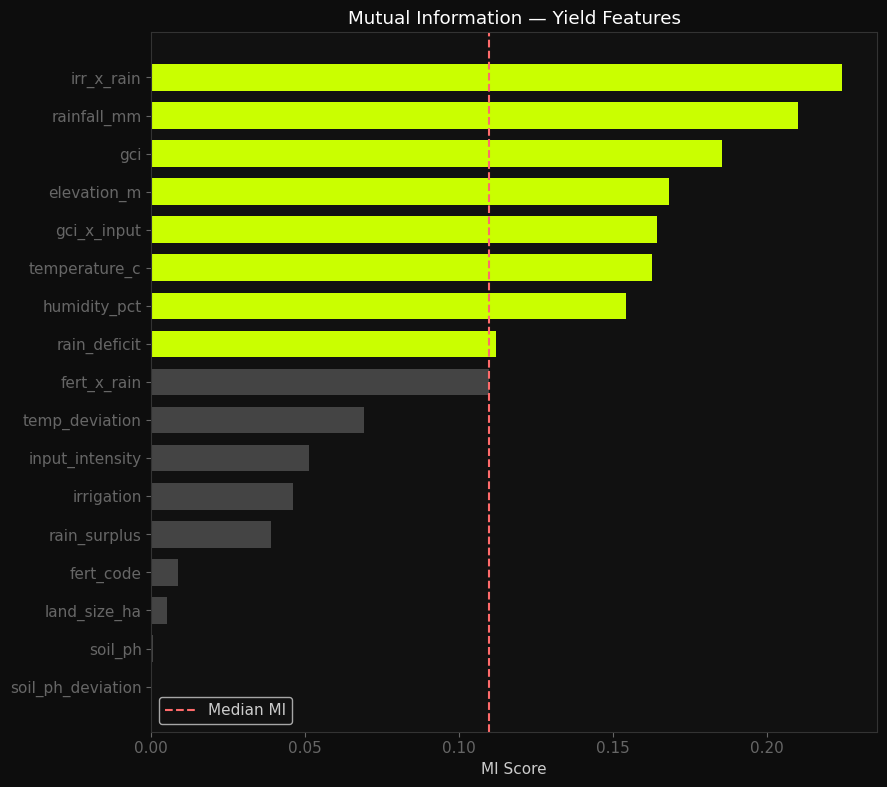


Top yield features by MI: ['rain_deficit', 'humidity_pct', 'temperature_c', 'gci_x_input', 'elevation_m', 'gci', 'rainfall_mm', 'irr_x_rain']


In [23]:
# ── 6.1 Mutual information — yield target ─────────────────────────────────
X_mi = yields_fe[YIELD_NUMERIC_FEATURES].dropna()
y_mi = yields_fe.loc[X_mi.index, 'yield_tons_per_ha']

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_df = pd.Series(mi_scores, index=YIELD_NUMERIC_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = [LIME if v > mi_df.median() else '#444444' for v in mi_df.values]
ax.barh(mi_df.index, mi_df.values, color=colors, edgecolor='none', height=0.7)
ax.axvline(mi_df.median(), color='#FF6B6B', lw=1.5, linestyle='--', label='Median MI')
ax.set_title('Mutual Information — Yield Features')
ax.set_xlabel('MI Score')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'feature_importance_mi_yield.png', dpi=140, bbox_inches='tight')
plt.show()

top_yield_feats = mi_df[mi_df > mi_df.median()].index.tolist()
print('\nTop yield features by MI:', top_yield_feats)

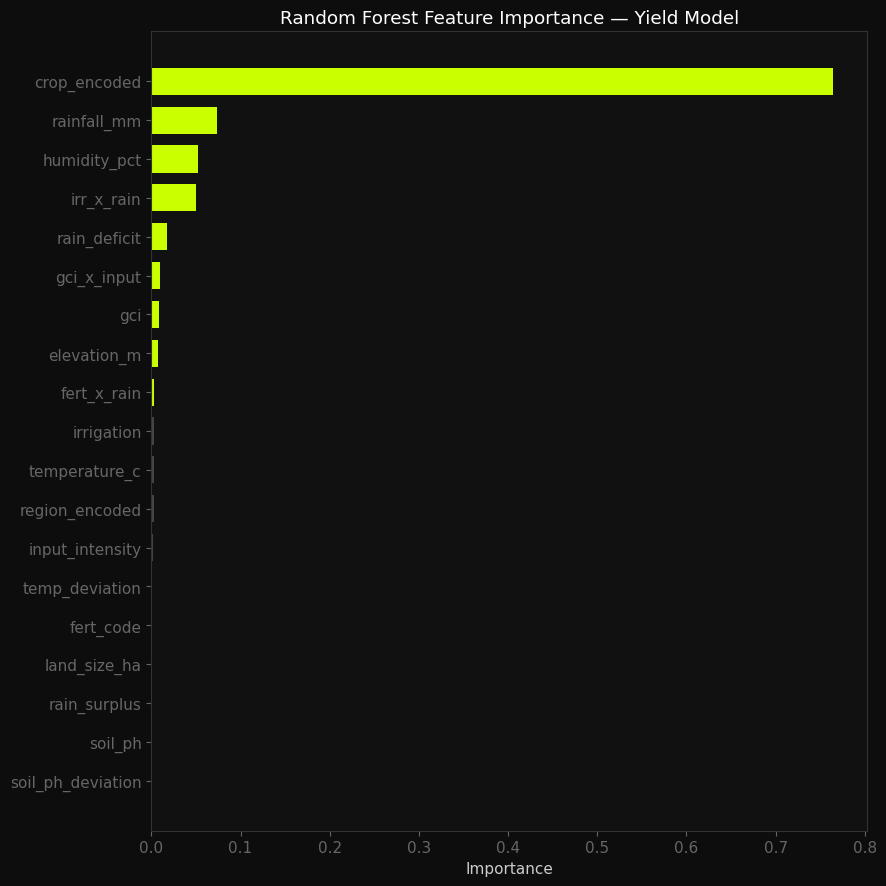


RF R² on test set: 0.9925
Top quartile features: ['rain_deficit', 'irr_x_rain', 'humidity_pct', 'rainfall_mm', 'crop_encoded']


In [24]:
# ── 6.2 Random Forest feature importance — yield ──────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_rf = yields_fe[YIELD_NUMERIC_FEATURES + YIELD_CAT_FEATURES].dropna()
y_rf = yields_fe.loc[X_rf.index, 'yield_tons_per_ha']

X_tr, X_te, y_tr, y_te = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

importances = pd.Series(rf.feature_importances_,
                         index=YIELD_NUMERIC_FEATURES + YIELD_CAT_FEATURES
                         ).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
colors = [LIME if v > importances.median() else '#444444' for v in importances.values]
ax.barh(importances.index, importances.values, color=colors, edgecolor='none', height=0.7)
ax.set_title('Random Forest Feature Importance — Yield Model')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'feature_importance_rf_yield.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'\nRF R² on test set: {rf.score(X_te, y_te):.4f}')
top_rf = importances[importances > importances.quantile(.75)].index.tolist()
print('Top quartile features:', top_rf)

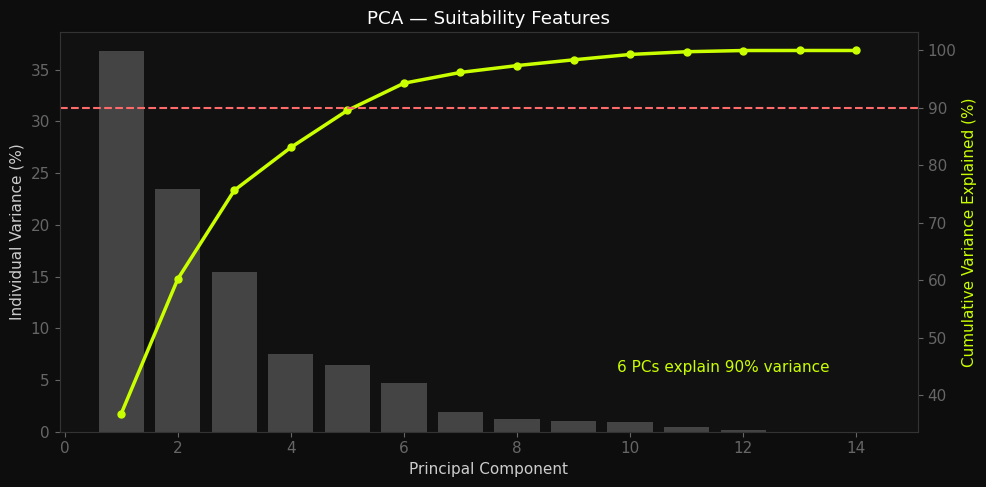

In [25]:
# ── 6.3 PCA variance explained — suitability features ─────────────────────
X_pca = StandardScaler().fit_transform(yields_fe[SUIT_FEATURES].dropna())
pca = PCA(n_components=len(SUIT_FEATURES), random_state=42)
pca.fit(X_pca)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained)+1), explained*100, color='#444444', label='Individual variance')
ax2 = ax.twinx()
ax2.plot(range(1, len(cumulative)+1), cumulative*100, color=LIME, lw=2.5, marker='o', markersize=5, label='Cumulative')
ax2.axhline(90, color='#FF6B6B', lw=1.5, linestyle='--', label='90% threshold')
ax2.set_ylabel('Cumulative Variance Explained (%)', color=LIME)
ax.set_xlabel('Principal Component'); ax.set_ylabel('Individual Variance (%)')
ax.set_title('PCA — Suitability Features')
n_comp_90 = (cumulative >= 0.90).argmax() + 1
ax.text(0.65, 0.15, f'{n_comp_90} PCs explain 90% variance',
        transform=ax.transAxes, color=LIME, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'pca_suitability.png', dpi=140, bbox_inches='tight')
plt.show()

## 7. Save Engineered Datasets

In [26]:
# ── 7.1 Save all engineered datasets ──────────────────────────────────────
# Note: Removed the redundant 'from pandas.io.parquet import to_parquet' line

# Explicitly defining the engine protects against internal registration collisions
price_national.to_parquet(OUTPUT_DIR / 'price_features.parquet', index=False, engine='pyarrow')
yields_fe.to_parquet(     OUTPUT_DIR / 'yield_features.parquet',  index=False, engine='pyarrow')
risk_df.to_parquet(        OUTPUT_DIR / 'risk_features.parquet',   index=False, engine='pyarrow')

# Save feature column lists for use in modelling notebooks
joblib.dump({
    'price':       PRICE_FEATURE_COLS,
    'yield':       YIELD_NUMERIC_FEATURES + YIELD_CAT_FEATURES,
    'suitability': SUIT_FEATURES,
    'risk':        RISK_FEATURES_AVAIL,
    'top_yield':   top_yield_feats,
    'top_rf':      top_rf,
}, MODELS_DIR / 'feature_cols.pkl')

print('Saved:')
for f in [OUTPUT_DIR/'price_features.parquet',
          OUTPUT_DIR/'yield_features.parquet',
          OUTPUT_DIR/'risk_features.parquet',
          MODELS_DIR/'feature_cols.pkl']:
    sz = f.stat().st_size / 1024
    print(f'  {f.name:35s}  {sz:.1f} KB')

Saved:
  price_features.parquet               1330.9 KB
  yield_features.parquet               321.7 KB
  risk_features.parquet                83.3 KB
  feature_cols.pkl                     0.9 KB


In [27]:
# ── 7.2 Feature engineering summary ───────────────────────────────────────
print('=' * 60)
print('  FEATURE ENGINEERING SUMMARY')
print('=' * 60)
print(f'\nPrice features    : {len(PRICE_FEATURE_COLS)} columns')
print(f'Yield features    : {len(YIELD_NUMERIC_FEATURES + YIELD_CAT_FEATURES)} columns')
print(f'Suitability feats : {len(SUIT_FEATURES)} columns')
print(f'Risk features     : {len(RISK_FEATURES_AVAIL)} columns')
print()
print('Key engineered features:')
print('  [Price]  lag_1w..52w, rolling mean/std/cv, Fourier pairs, log-diff')
print('  [Yield]  GCI, input_intensity, rain_deficit, temp_deviation, interactions')
print('  [Risk]   financial_risk (from CV), climate_risk (composite), agronomic_risk (rule-based)')
print()
print('Saved artifacts:')
print('  outputs/features/  — parquet feature tables')
print('  models/            — scalers, encoders, feature lists')
print('=' * 60)

  FEATURE ENGINEERING SUMMARY

Price features    : 27 columns
Yield features    : 19 columns
Suitability feats : 14 columns
Risk features     : 6 columns

Key engineered features:
  [Price]  lag_1w..52w, rolling mean/std/cv, Fourier pairs, log-diff
  [Yield]  GCI, input_intensity, rain_deficit, temp_deviation, interactions
  [Risk]   financial_risk (from CV), climate_risk (composite), agronomic_risk (rule-based)

Saved artifacts:
  outputs/features/  — parquet feature tables
  models/            — scalers, encoders, feature lists
